In [16]:
run_gridsearch = False
skip_best_model_validation = False
skip_best_model_test = False
verbose = True
GPU_SETTING = -1
NUM_ENSEMBLES = 5
BASIN = "warm_springs"
RES_1H = "mts_hourly"
RES_1D = "mts_daily"
RUN_LABEL = "BASELINE"
MODE = "mts"
READ_STAMP = "20250815T000000Z"

In [17]:
hyperparam_space = {
    "hidden_size": [64, 128, 256],
    "output_dropout": [0.4],
    "seq_length_1D": [90, 120],
    "seq_length_1H": [168, 336],
    "num_layers": [1],
    "epochs": [16, 32, 48],
    "batch_size": [64, 128],
    "schedule_pairs": [
        ((0.5, 0.25), (0.01, 0.005, 0.001))
    ]
}

In [18]:
import sys
import pandas as pd
import os
import itertools
from pathlib import Path
from tqdm import tqdm
import warnings
from datetime import datetime
warnings.simplefilter(action='ignore', category=FutureWarning)

In [19]:
current_dir = os.getcwd()
print(current_dir)

/Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/warm_springs


In [20]:
library_path = os.path.join('..', '..', '..','..','UCB-USACE-RR-PROJECT')
sys.path.insert(0, library_path)
print(sys.path)

['../../../../UCB-USACE-RR-PROJECT', '../../../../UCB-USACE-RR-PROJECT', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/maxwellfung/UCB-USACE-RR-PROJECT/venv/lib/python3.11/site-packages', '/Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/warm_springs/../../../../UCB-USACE-RR-PROJECT', '/Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/warm_springs/../../../../UCB-USACE-RR-PROJECT']


In [21]:
from neuralhydrology.evaluation.metrics import *
from UCB_training.UCB_train import UCB_trainer
from UCB_training.UCB_utils import (fractional_multi_lr, write_paths, to_path_or_list, ensure_output_tree, set_active_context, data_dir, repo_root, get_output_dir, make_run_stamp, get_yaml_path, ctx_for, hparams_exists, save_hparams, load_hparams, runs_latest_path, archive_runs_json, read_csv_artifact, ensure_shared_tree, ensure_absolute_basin_files)
from UCB_training.UCB_plotting import (plot_timeseries_comparison, scatter_triptych_pngs_v3, ts_triptych_v3)

In [22]:
current_path = os.getcwd()
library_path = current_path.split('UCB-USACE-RR-PROJECT')[0] + 'UCB-USACE-RR-PROJECT'

In [23]:
RUNS_FILE = str(runs_latest_path(BASIN, MODE, RUN_LABEL))
SHOULD_STAMP = not (skip_best_model_validation and skip_best_model_test)
RUN_STAMP = make_run_stamp() if SHOULD_STAMP else None
ACTIVE_STAMP = RUN_STAMP if RUN_STAMP is not None else READ_STAMP

In [24]:
switch_ctx = ctx_for(BASIN, run_stamp=ACTIVE_STAMP, run_label=RUN_LABEL, append_stamp_to_filenames=False)
_SHARED = ensure_shared_tree(BASIN, MODE)
RUNS_PARENT = _SHARED / "runs" / (f"{RUN_LABEL}_{RUN_STAMP}" if RUN_STAMP else RUN_LABEL)

print("NH runs will be written under:")
print(RUNS_PARENT.resolve())

NH runs will be written under:
/Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/warm_springs/mts_shared/runs/BASELINE_20260204T061432Z


In [25]:
path_to_csv = data_dir()
path_to_yaml = get_yaml_path("warm_springs_mtslstm2")
path_to_physics_data_1D = path_to_csv / "WarmSprings_Inflow_daily_averaged.csv"
path_to_physics_data_1H = path_to_csv / "WarmSprings_Inflow_hourly.csv"

In [26]:
features_with_physics = [
    #from daily.csv
    "DRY CREEK 20 PRECIP-INC SCREENED",
    "DRY CREEK 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "DRY CREEK 30 PRECIP-INC SCREENED",
    "DRY CREEK 30 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "UKIAH CA HUMIDITY USAF-NOAA",
    "UKIAH CA SOLAR RADIATION USAF-NOAA",
    "UKIAH CA TEMPERATURE USAF-NOAA",
    "UKIAH CA WINDSPEED USAF-NOAA",
    "SANTA ROSA CA HUMIDITY USAF-NOAA",
    "SANTA ROSA CA SOLAR RADIATION USAF-NOAA",
    "SANTA ROSA CA TEMPERATURE USAF-NOAA",
    "SANTA ROSA CA WINDSPEED USAF-NOAA",
    #from Warm_Spring_Inflow.csv
    'Dry Creek 20 ET-POTENTIAL',
    'Dry Creek 20 FLOW',
    'Dry Creek 20 FLOW-BASE',
    'Dry Creek 20 INFILTRATION',
    'Dry Creek 20 PERC-SOIL',
    'Dry Creek 20 SATURATION FRACTION',
    'Dry Creek 30 ET-POTENTIAL',
    'Dry Creek 30 FLOW',
    'Dry Creek 30 FLOW-BASE',
    'Dry Creek 30 INFILTRATION',
    'Dry Creek 30 PERC-SOIL',
    'Dry Creek 30 SATURATION FRACTION',
    'Warm Springs Dam Inflow FLOW',
]

In [27]:
no_physics_results = []
physics_results = []

In [28]:
GRID_RANK = "NSE_1H"   # NSE_1H or NSE_1D 

In [29]:
start_time = datetime.utcnow()
print("Start time:", start_time.strftime("%Y-%m-%d %H:%M:%S"))

Start time: 2026-02-04 06:14:32


run_gridsearch = False
hparams_exists = False


Grid-Search:   0%|                   | 0/72 [00:00<?, ?it/s]


NoPhysics: {'hidden_size': 64, 'output_dropout': 0.4, 'seq_length': {'1D': 90, '1H': 168}, 'num_layers': 1, 'epochs': 16, 'batch_size': 64, 'learning_rate': {0: 0.01, 8: 0.005, 12: 0.001}}
[UCB_trainer:_create_config] Injected missing train_start_date → 01/01/1900
[UCB_trainer:_create_config] Injected missing train_end_date → 01/01/1901
[UCB_trainer:_create_config] Injected missing validation_start_date → 01/01/1900
[UCB_trainer:_create_config] Injected missing validation_end_date → 01/01/1901
[UCB_trainer:_create_config] Injected missing test_start_date → 01/01/1900
[UCB_trainer:_create_config] Injected missing test_end_date → 01/01/1901
[UCB Trainer] Using CPU (unhandled gpu=-1).
2026-02-03 22:14:45,007: Logging to /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/warm_springs/mts_shared/runs/BASELINE_20260204T061432Z/testing_run_0302_221445/output.log initialized.
2026-02-03 22:14:45,007: ### Folder structure created at /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/warm_springs/mts

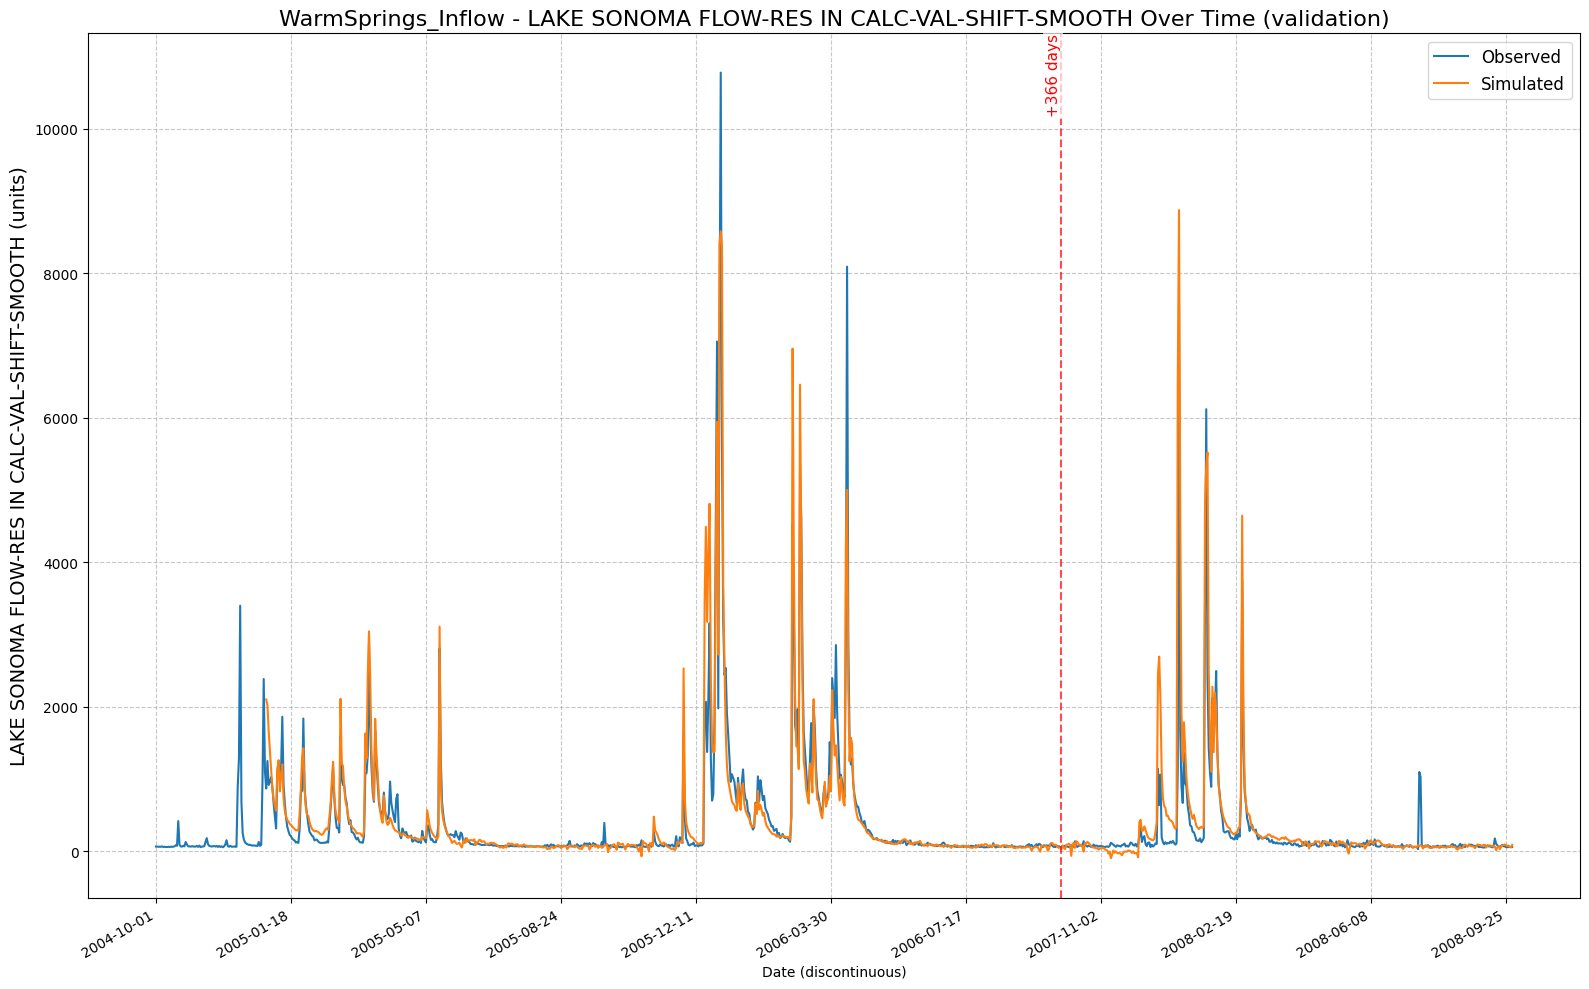

[UCB_trainer] Restoring synthetic validation dates for analysis...
[UCB_trainer] _observed restored coord 'date': 2004-10-01 00:00:00 → 2008-09-30 00:00:00
[UCB_trainer] _predictions restored coord 'date': 2004-10-01 00:00:00 → 2008-09-30 00:00:00


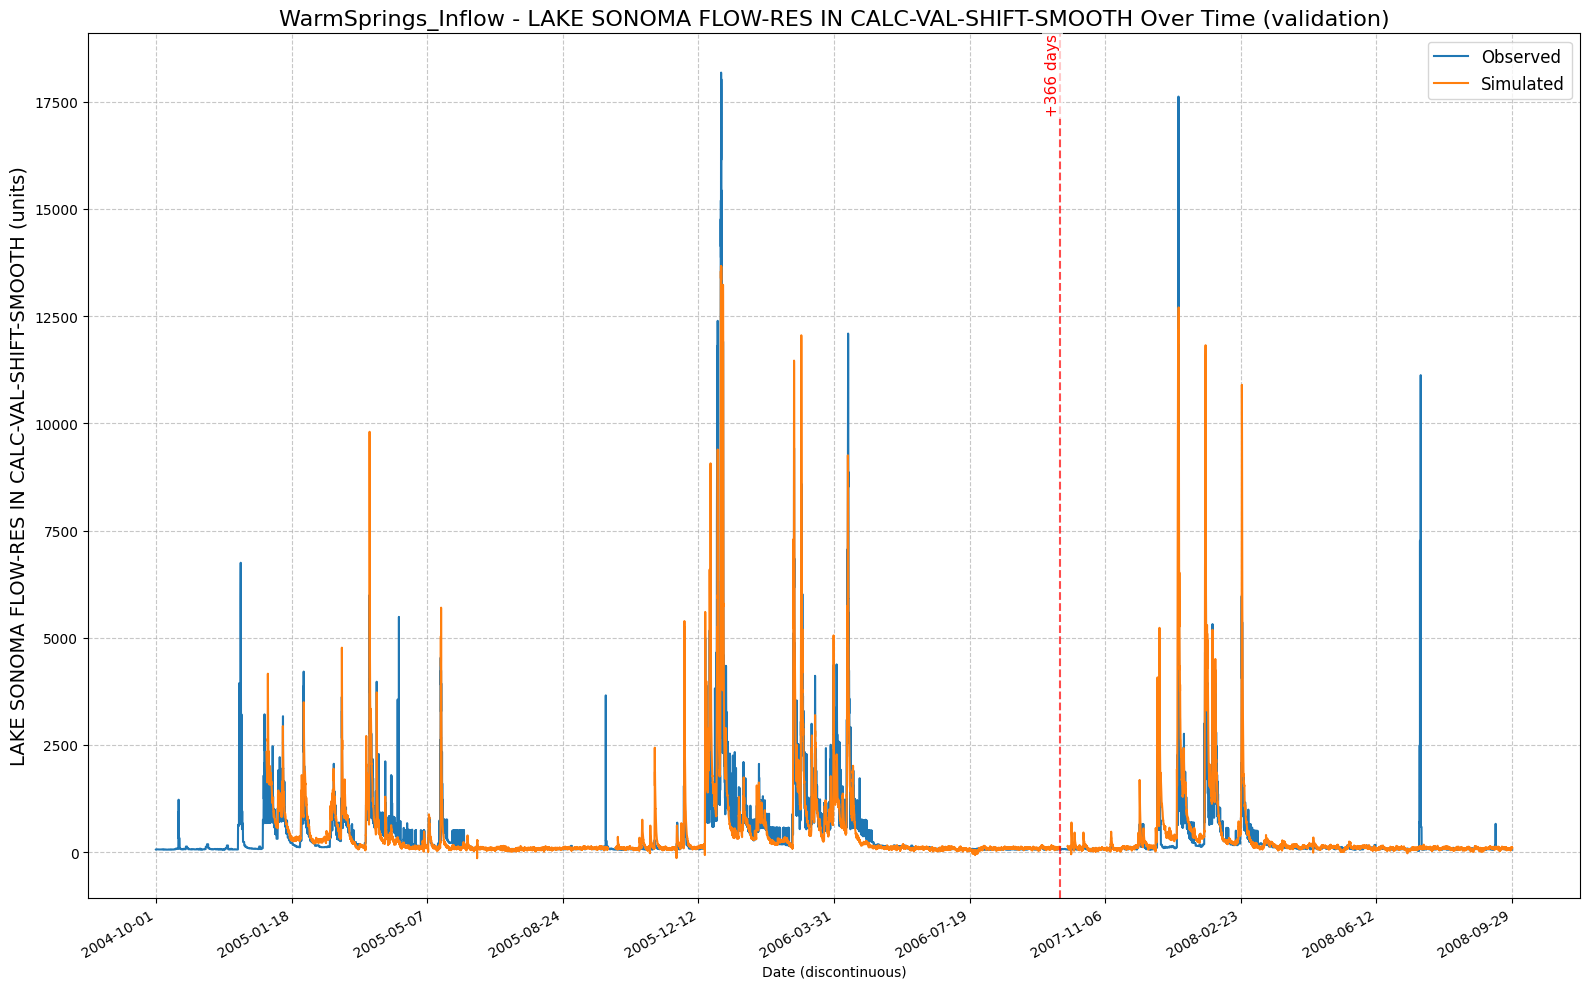

Grid-Search:   1%|1        | 1/72 [01:00<1:11:36, 60.52s/it]


NoPhysics: {'hidden_size': 64, 'output_dropout': 0.4, 'seq_length': {'1D': 90, '1H': 168}, 'num_layers': 1, 'epochs': 16, 'batch_size': 128, 'learning_rate': {0: 0.01, 8: 0.005, 12: 0.001}}
[UCB_trainer:_create_config] Injected missing train_start_date → 01/01/1900
[UCB_trainer:_create_config] Injected missing train_end_date → 01/01/1901
[UCB_trainer:_create_config] Injected missing validation_start_date → 01/01/1900
[UCB_trainer:_create_config] Injected missing validation_end_date → 01/01/1901
[UCB_trainer:_create_config] Injected missing test_start_date → 01/01/1900
[UCB_trainer:_create_config] Injected missing test_end_date → 01/01/1901
[UCB Trainer] Using CPU (unhandled gpu=-1).
2026-02-03 22:15:45,528: Logging to /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/warm_springs/mts_shared/runs/BASELINE_20260204T061432Z/testing_run_0302_221545/output.log initialized.
2026-02-03 22:15:45,529: ### Folder structure created at /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/warm_springs/mt

Grid-Search:   1%|1        | 1/72 [01:22<1:37:32, 82.43s/it]

KeyboardInterrupt: 

In [31]:
print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

hyperparam_names = []
for i, hp in enumerate(hyperparam_space.keys()):
    hyperparam_names.append(hp)

total_iters = 1
for name in hyperparam_names:
    total_iters *= len(hyperparam_space[name])

if run_gridsearch or not hparams_exists(BASIN, MODE, RUN_LABEL):
    for combinations in tqdm(
        itertools.product(*[hyperparam_space[hp] for hp in hyperparam_names]), 
        desc="Grid-Search", 
        total=total_iters, 
        unit="it", 
        ncols=60, 
        ascii=True):

        hp_run = {}
        j = 0
        schedule_pairs = None
        
        while j < len(hyperparam_names):
            name = hyperparam_names[j]
            val  = combinations[j]

            if name in ("seq_length_1D", "seq_length_1H"):
                hp_run["seq_length"] = {"1D": combinations[j], "1H": combinations[j + 1]}
                j += 2
                continue

            if name == "schedule_pairs":
                schedule_pairs = val
                j += 1
                continue

            hp_run[name] = val
            j += 1

        if schedule_pairs is not None:
            fractions, rates = schedule_pairs
            hp_run["learning_rate"] = fractional_multi_lr(
                epochs=int(hp_run["epochs"]), fractions=list(fractions), lrs=list(rates))
        else:
            hp_run.setdefault("learning_rate", {0: 0.01, 30: 0.005, 40: 0.001})

        if verbose:
            print(f"\nNoPhysics: {hp_run}")
            
        trainer = UCB_trainer(
            path_to_csv_folder=path_to_csv,
            yaml_path=path_to_yaml,
            hyperparams=hp_run,
            input_features=None,
            physics_informed=False,
            physics_data_file=None,
            hourly=True,  
            extend_train_period=False,
            gpu=GPU_SETTING,
            is_mts = True,
            verbose=verbose,
            runs_parent=RUNS_PARENT,
            run_label=RUN_LABEL,
            run_stamp=RUN_STAMP)
        
        trainer.train()
        csv_1d, metrics_1d = trainer.results(period="validation", mts_trk="1D")
        csv_1h, metrics_1h = trainer.results(period="validation", mts_trk="1H")
        
        row_data = {}
        j = 0
        while j < len(hyperparam_names):
            row_data[hyperparam_names[j]] = combinations[j]
            j += 1
            
        row_data["learning_rate"] = str(hp_run["learning_rate"])
        
        for k, v in metrics_1d.items():
            row_data[f"{k}_1D"] = v
        for k, v in metrics_1h.items():
            row_data[f"{k}_1H"] = v
        
        no_physics_results.append(row_data)
        
    df_no_physics = pd.DataFrame(no_physics_results)
    df_no_physics.sort_values(by=GRID_RANK, ascending=False, inplace=True)
    df_no_physics.reset_index(drop=True, inplace=True)
else:
    print("Skipping grid search!")

print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

In [ ]:
if run_gridsearch or not hparams_exists(BASIN, MODE, RUN_LABEL):    
    for combinations in tqdm(
        itertools.product(*[hyperparam_space[hp] for hp in hyperparam_names]), 
        desc="Grid-Search", 
        total=total_iters, 
        unit="it", 
        ncols=60, 
        ascii=True):

        hp_run = {}
        j = 0
        schedule_pairs = None
        
        while j < len(hyperparam_names):
            name = hyperparam_names[j]
            val  = combinations[j]

            if name in ("seq_length_1D", "seq_length_1H"):
                hp_run["seq_length"] = {"1D": combinations[j], "1H": combinations[j + 1]}
                j += 2
                continue

            if name == "schedule_pairs":
                schedule_pairs = val
                j += 1
                continue

            hp_run[name] = val
            j += 1

        if schedule_pairs is not None:
            fractions, rates = schedule_pairs
            hp_run["learning_rate"] = fractional_multi_lr(
                epochs=int(hp_run["epochs"]), fractions=list(fractions), lrs=list(rates))
        else:
            hp_run.setdefault("learning_rate", {0: 0.01, 30: 0.005, 40: 0.001})
                
        if verbose:
            print(f"\nPhysics: {hp_run}")
            
        trainer = UCB_trainer(
            path_to_csv_folder=path_to_csv,
            yaml_path=path_to_yaml,
            hyperparams=hp_run,
            input_features=features_with_physics,
            physics_informed=True,
            physics_data_file=path_to_physics_data_1H,
            hourly=True,
            extend_train_period=False,
            gpu=GPU_SETTING,
            is_mts = True,
            verbose=verbose,
            runs_parent=RUNS_PARENT,
            run_label=RUN_LABEL,
            run_stamp=RUN_STAMP)
        
        trainer.train()
        csv_1d, metrics_1d = trainer.results(period="validation", mts_trk="1D")
        csv_1h, metrics_1h = trainer.results(period="validation", mts_trk="1H")

        row_data = {}
        j = 0
        while j < len(hyperparam_names):
            row_data[hyperparam_names[j]] = combinations[j]
            j += 1
            
        row_data["learning_rate"] = str(hp_run["learning_rate"])

        for k, v in metrics_1d.items():
            row_data[f"{k}_1D"] = v
        for k, v in metrics_1h.items():
            row_data[f"{k}_1H"] = v
            
        physics_results.append(row_data)
    df_physics = pd.DataFrame(physics_results)
    df_physics.sort_values(by=GRID_RANK, ascending=False, inplace=True)
    df_physics.reset_index(drop=True, inplace=True)
    best_no_phys = df_no_physics.iloc[0].to_dict()
    best_phys = df_physics.iloc[0].to_dict()
    best_no_phys["model_type"] = "no_physics"
    best_phys["model_type"] = "physics"
    best_params_df = pd.DataFrame([best_no_phys, best_phys])
    save_hparams(best_df=best_params_df, basin=BASIN, mode=MODE, label=RUN_LABEL, run_stamp=RUN_STAMP, df_no=df_no_physics, df_phys=df_physics)
else:
    print("Skipping grid search!")

In [ ]:
try:
    if run_gridsearch:
        print("\n[INFO] Using best_params_df from the just-completed grid search (ignoring READ_STAMP).")
    else:
        print("\nLoading best hyperparams from CSV...")
        best_params_df = load_hparams(BASIN, MODE, RUN_LABEL, stamp=READ_STAMP)
except FileNotFoundError as e:
    raise SystemExit(f"[ERROR] {e}  (Set run_gridsearch=True to generate it.)")

best_no_phys = best_params_df.query("model_type == 'no_physics'").iloc[0].to_dict()
best_phys = best_params_df.query("model_type == 'physics'").iloc[0].to_dict()

best_no_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]

    if name == "output_dropout":
        best_no_physics_params[name] = float(best_no_phys[name])
        j += 1

    elif name in ("seq_length_1D", "seq_length_1H"):

        best_no_physics_params["seq_length"] = {
            "1D": int(best_no_phys["seq_length_1D"]),
            "1H": int(best_no_phys["seq_length_1H"])}
        j += 2

    elif name == "schedule_pairs":
        j += 1

    else:
        best_no_physics_params[name] = int(best_no_phys[name])
        j += 1

if "learning_rate" in best_no_phys and pd.notna(best_no_phys["learning_rate"]):

    best_no_physics_params["learning_rate"] = eval(str(best_no_phys["learning_rate"]))

elif "schedule_pairs" in best_no_phys and pd.notna(best_no_phys["schedule_pairs"]):
    sp = best_no_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_no_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_no_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_no_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

best_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]

    if name == "output_dropout":
        best_physics_params[name] = float(best_phys[name])
        j += 1

    elif name in ("seq_length_1D", "seq_length_1H"):
        best_physics_params["seq_length"] = {
            "1D": int(best_phys["seq_length_1D"]),
            "1H": int(best_phys["seq_length_1H"])}
        j += 2

    elif name == "schedule_pairs":
        j += 1

    else:
        best_physics_params[name] = int(best_phys[name])
        j += 1

if "learning_rate" in best_phys and pd.notna(best_phys["learning_rate"]):
    best_physics_params["learning_rate"] = eval(str(best_phys["learning_rate"]))

elif "schedule_pairs" in best_phys and pd.notna(best_phys["schedule_pairs"]):
    sp = best_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

print("Loaded best hyperparams from CSV:")
print("Best NO-PHYS:", best_no_physics_params)
print("Best PHYS:", best_physics_params)

#tempoverride:
best_no_physics_params["epochs"] = 2
best_physics_params["epochs"] = 2

In [ ]:
if not skip_best_model_validation:
    noPhysValTrainer = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=True,
        extend_train_period=False,
        gpu=GPU_SETTING,
        is_mts = True,
        # num_ensemble_members = NUM_ENSEMBLES,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    noPhysValTrainer.train()
    noPhys_val_csv_1D, noPhys_val_metrics_1D = noPhysValTrainer.results(period="validation", mts_trk="1D")
    noPhys_val_csv_1H, noPhys_val_metrics_1H = noPhysValTrainer.results(period="validation", mts_trk="1H")
    print("NO-PHYS VAL 1D => NSE =", noPhys_val_metrics_1D.get("NSE", None))
    print("NO-PHYS VAL 1H => NSE =", noPhys_val_metrics_1H.get("NSE", None))

In [ ]:
if not skip_best_model_validation:
    physValTrainer = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data_1H,
        hourly=True,
        extend_train_period=False,
        gpu=GPU_SETTING,
        is_mts = True,
        # num_ensemble_members = NUM_ENSEMBLES,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    physValTrainer.train()
    phys_val_csv_1D, phys_val_metrics_1D = physValTrainer.results(period="validation", mts_trk="1D")
    phys_val_csv_1H, phys_val_metrics_1H = physValTrainer.results(period="validation", mts_trk="1H")
    print("PHYS VAL 1D => NSE =", phys_val_metrics_1D.get("NSE", None))
    print("PHYS VAL 1H => NSE =", phys_val_metrics_1H.get("NSE", None))

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Warm Springs Basin MTS 1D Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_val_metrics_1D.csv", ts_out="warm_springs_mts_val_1D_combined_ts.csv", fig_out="warm_springs_mts_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_val_1D = read_csv_artifact("warm_springs_mts_val_1D_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_val_1D, title="Warm Springs Basin MTS 1D Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_val_metrics_1D.csv", ts_out="warm_springs_mts_val_1D_combined_ts.csv", fig_out="warm_springs_mts_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Warm Springs Basin MTS 1H Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_val_metrics_1H.csv", ts_out="warm_springs_mts_val_1H_combined_ts.csv", fig_out="warm_springs_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_val_1H = read_csv_artifact("warm_springs_mts_val_1H_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_val_1H, title="Warm Springs Basin MTS 1H Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_val_metrics_1H.csv", ts_out="warm_springs_mts_val_1H_combined_ts.csv", fig_out="warm_springs_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if skip_best_model_validation:
    val_metrics = read_csv_artifact("warm_springs_mts_val_metrics_1D.csv",  kind="metrics", period="validation", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
    print(val_metrics)

In [ ]:
switch_ctx(RES_1H)

if skip_best_model_validation:
    val_metrics = read_csv_artifact("warm_springs_mts_val_metrics_1H.csv",  kind="metrics", period="validation", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
    print(val_metrics)

# Test Period

In [ ]:
if not skip_best_model_test:
    print("\nTraining No-Physics MTS model for test period...")
    mtsNoPhysicsTest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=True,
        extend_train_period=True,
        gpu=GPU_SETTING,
        is_mts = True,
        verbose=verbose,
        # num_ensemble_members = NUM_ENSEMBLES,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)

    ensure_absolute_basin_files(mtsNoPhysicsTest, BASIN)
    
    mtsNoPhysicsTest.train()
    no_physics_test_csv_1D, no_physics_test_metrics_1D = mtsNoPhysicsTest.results(period="test", mts_trk="1D")
    no_physics_test_csv_1H, no_physics_test_metrics_1H = mtsNoPhysicsTest.results(period="test", mts_trk="1H")
    print("\n[No-Physics Test] NSE @1D =", no_physics_test_metrics_1D.get("NSE", None))
    print("[No-Physics Test] NSE @1H =", no_physics_test_metrics_1H.get("NSE", None))

In [ ]:
if not skip_best_model_test:
    print("\nTraining Physics MTS model for test period...")
    mtsPhysicsTest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data_1H,
        hourly=True,
        extend_train_period=True,
        gpu=GPU_SETTING,
        is_mts = True,
        # num_ensemble_members = NUM_ENSEMBLES,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)

    ensure_absolute_basin_files(mtsPhysicsTest, BASIN)
    
    mtsPhysicsTest.train()
    physics_test_csv_1D, physics_test_metrics_1D = mtsPhysicsTest.results(period="test", mts_trk="1D")
    physics_test_csv_1H, physics_test_metrics_1H = mtsPhysicsTest.results(period="test", mts_trk="1H")
    print("\n[Physics Test] NSE @1D =", physics_test_metrics_1D.get("NSE", None))
    print("[Physics Test] NSE @1H =", physics_test_metrics_1H.get("NSE", None))

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Basin MTS 1D Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_test_1D = read_csv_artifact("warm_springs_mts_test_1D_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Basin MTS 1D Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Basin MTS 1D Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Basin MTS 1D Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Basin MTS 1H Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_test_1H = read_csv_artifact("warm_springs_mts_test_1H_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Basin MTS 1H Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Basin MTS 1H Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Basin MTS 1H Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

test_metrics = read_csv_artifact("warm_springs_mts_test_metrics_1D.csv", kind="metrics", period="test", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
print(test_metrics)

In [ ]:
switch_ctx(RES_1H)

test_metrics = read_csv_artifact("warm_springs_mts_test_metrics_1H.csv", kind="metrics", period="test", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
print(test_metrics)

In [ ]:
if not skip_best_model_test:
    write_paths("no_physics", mtsNoPhysicsTest, filename = RUNS_FILE)
    write_paths("physics", mtsPhysicsTest, filename = RUNS_FILE)
    archived_path = archive_runs_json(Path(RUNS_FILE), BASIN, MODE, RUN_LABEL, RUN_STAMP)

In [ ]:
end_time = datetime.utcnow()
print("End time:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Total time:", end_time - start_time)

##### Additional Plots

In [ ]:
if skip_best_model_validation:
    switch_ctx(RES_1D)
    combined_df_daily_val = read_csv_artifact("warm_springs_mts_val_1D_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    switch_ctx(RES_1H)
    combined_df_hourly_val = read_csv_artifact("warm_springs_mts_val_1H_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    
if skip_best_model_test:
    switch_ctx(RES_1D)
    combined_df_daily = read_csv_artifact("warm_springs_mts_test_1D_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    switch_ctx(RES_1H)
    combined_df_hourly = read_csv_artifact("warm_springs_mts_test_1H_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)

In [ ]:
metric_list = ["NSE", "PBIAS"]

wettest_start_val = "2003-10-01"
wettest_end_val = "2004-09-30"
dryest_start_val = "2004-10-01"
dryest_end_val = "2005-09-30"
wettest_start_test = "2005-10-01"
wettest_end_test = "2006-09-30"
dryest_start_test = "2008-10-01"
dryest_end_test = "2009-09-30"

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_val_metrics_1D.csv", ts_out="warm_springs_mts_val_1D_combined_ts.csv", fig_out="warm_springs_mts_val_plot_1D.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_daily_val, title="Warm Springs Daily MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_val_metrics_1D.csv", ts_out="warm_springs_mts_val_1D_combined_ts.csv", fig_out="warm_springs_mts_val_plot_1D.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_val_metrics_1H.csv", ts_out="warm_springs_mts_val_1H_combined_ts.csv", fig_out="warm_springs_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_hourly_val, title="Warm Springs Hourly MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_val_metrics_1H.csv", ts_out="warm_springs_mts_val_1H_combined_ts.csv", fig_out="warm_springs_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Daily MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Daily MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1D.csv", ts_out="warm_springs_mts_test_1D_combined_ts.csv", fig_out="warm_springs_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Hourly MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Hourly MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="warm_springs_mts_test_metrics_1H.csv", ts_out="warm_springs_mts_test_1H_combined_ts.csv", fig_out="warm_springs_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
# EVERYTHING BELOW HERE MEASURES EXTREME YEARS.

raise SystemExit("EVERYTHING BELOW HERE MEASURES EXTREME YEARS WITH HARDCODED VALUES AND DOESNT MAKE SENSE FOR SYNTHETIC")

##### Wettest Year Performance

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="warm_springs_mts_wet_val_metrics_1D.csv", ts_out="warm_springs_mts_wet_val_1D_combined_ts.csv", fig_out="warm_springs_mts_wet_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_daily_val, title="Warm Springs Daily MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="warm_springs_mts_wet_val_metrics_1D.csv", ts_out="warm_springs_mts_wet_val_1D_combined_ts.csv", fig_out="warm_springs_mts_wet_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="warm_springs_mts_wet_val_metrics_1H.csv", ts_out="warm_springs_mts_wet_val_1H_combined_ts.csv", fig_out="warm_springs_mts_wet_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_hourly_val, title="Warm Springs Hourly MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="warm_springs_mts_wet_val_metrics_1H.csv", ts_out="warm_springs_mts_wet_val_1H_combined_ts.csv", fig_out="warm_springs_mts_wet_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1D.csv", ts_out="warm_springs_mts_wet_test_1D_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Daily MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1D.csv", ts_out="warm_springs_mts_wet_test_1D_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1D.csv", ts_out="warm_springs_mts_wet_test_1D_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Daily MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1D.csv", ts_out="warm_springs_mts_wet_test_1D_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1H.csv", ts_out="warm_springs_mts_wet_test_1H_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="warm_springs Hourly MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1H.csv", ts_out="warm_springs_mts_wet_test_1H_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1H.csv", ts_out="warm_springs_mts_wet_test_1H_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Hourly MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="warm_springs_mts_wet_test_metrics_1H.csv", ts_out="warm_springs_mts_wet_test_1H_combined_ts.csv", fig_out="warm_springs_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)

##### Driest Year Performance

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="warm_springs_mts_dry_val_metrics_1D.csv", ts_out="warm_springs_mts_dry_val_1D_combined_ts.csv", fig_out="warm_springs_mts_dry_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_daily_val, title="Warm Springs Daily MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="warm_springs_mts_dry_val_metrics_1D.csv", ts_out="warm_springs_mts_dry_val_1D_combined_ts.csv", fig_out="warm_springs_mts_dry_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="warm_springs_mts_dry_val_metrics_1H.csv", ts_out="warm_springs_mts_dry_val_1H_combined_ts.csv", fig_out="warm_springs_mts_dry_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_hourly_val, title="Warm Springs Hourly MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="warm_springs_mts_dry_val_metrics_1H.csv", ts_out="warm_springs_mts_dry_val_1H_combined_ts.csv", fig_out="warm_springs_mts_dry_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1D.csv", ts_out="warm_springs_mts_dry_test_1D_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Daily MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1D.csv", ts_out="warm_springs_mts_dry_test_1D_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Warm Springs Daily MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1D.csv", ts_out="warm_springs_mts_dry_test_1D_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Warm Springs Daily MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1D.csv", ts_out="warm_springs_mts_dry_test_1D_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1H.csv", ts_out="warm_springs_mts_dry_test_1H_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Hourly MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1H.csv", ts_out="warm_springs_mts_dry_test_1H_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Warm Springs Hourly MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1H.csv", ts_out="warm_springs_mts_dry_test_1H_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Warm Springs Hourly MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="warm_springs_mts_dry_test_metrics_1H.csv", ts_out="warm_springs_mts_dry_test_1H_combined_ts.csv", fig_out="warm_springs_mts_dry_test_1H_model_comparison.png", legend_font=12, axis_font=22)

##### Gridded Timeseries Plots - Validation and Test

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_validation:
    ts_triptych_v3((noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D),wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="warm_springs_mts_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Warm Springs MTS Daily Validation Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Validation period","Most-wet water-year","Most-dry water-year"))

else:
    ts_triptych_v3(combined_df_daily_val, wet_start=wettest_start_val , wet_end=wettest_end_val, dry_start=dryest_start_val,dry_end=dryest_end_val, save_path="warm_springs_mts_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Warm Springs MTS Daily Validation Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Validation Period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_validation:
    ts_triptych_v3((noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="warm_springs_mts_hourly_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Warm Springs MTS Hourly Validation Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Validation period","Most-wet water-year","Most-dry water-year")) 

else:
    ts_triptych_v3(combined_df_hourly_val, wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="warm_springs_mts_hourly_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Warm Springs MTS Hourly Validation Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Validation Period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    ts_triptych_v3((no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="warm_springs_mts_daily_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Warm Springs MTS Daily Test Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Test period","Most-wet water-year","Most-dry water-year"))
    
else:
    ts_triptych_v3(combined_df_daily, wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="warm_springs_mts_daily_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Warm Springs MTS Daily Test Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Test Period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    ts_triptych_v3((no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="warm_springs_mts_hourly_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Warm Springs MTS Hourly Test Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Test period","Most-wet water-year","Most-dry water-year"))
    
else:
    ts_triptych_v3(combined_df_hourly, wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="warm_springs_mts_hourly_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Warm Springs MTS Hourly Test Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Test Period", "Most‑wet water‑year","Most‑dry water‑year"))

##### Gridded Scatter Plots - Test

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    scatter_pngs = scatter_triptych_pngs_v3((no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test, dry_end = dryest_end_test, out_dir = "warm_springs_mts_daily_scatter", layout = "horizontal", square_side = 4.5, legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Warm Springs MTS Daily – Full test period", "Warm Springs MTS Daily – Wettest water‑year", "Warm Springs MTS Daily – Driest water‑year"), resolution="mts_daily")

else:
    scatter_pngs = scatter_triptych_pngs_v3(combined_df_daily, wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test, dry_end = dryest_end_test, out_dir = "warm_springs_mts_daily_scatter", layout = "horizontal", square_side = 4.5,legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Warm Springs MTS Daily – Full test period", "Warm Springs MTS Daily – Wettest water‑year", "Warm Springs MTS Daily – Driest water‑year"), resolution="mts_daily")

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    scatter_pngs = scatter_triptych_pngs_v3((no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test, dry_end = dryest_end_test, out_dir = "warm_springs_mts_hourly_scatter", layout = "horizontal", square_side = 4.5, legend_font = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Warm Springs MTS Hourly – Full test period", "Warm Springs MTS Hourly – Wettest water‑year", "Warm Springs MTS Hourly – Driest water‑year"), resolution="mts_hourly")
    
else:
    scatter_pngs = scatter_triptych_pngs_v3(combined_df_hourly, wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test,  dry_end = dryest_end_test, out_dir = "warm_springs_mts_hourly_scatter", layout = "horizontal", square_side = 4.5, legend_font = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Warm Springs MTS Hourly – Full test period", "Warm Springs MTS Hourly – Wettest water‑year", "Warm Springs MTS Hourly – Driest water‑year"), resolution="mts_hourly")